## 7. Remote At Center Platform

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ranksums
import seaborn as sns

In [2]:
from spyglass.shijiegu.Analysis_SGU import get_linearization_map

from spyglass.shijiegu.Analysis_SGU import TrialChoice, DecodeIngredients, DecodeResults2D, ChangeofMindTheta, DecodeResultsLinear
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.decoding.v0.visualization import make_single_environment_movie
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_triggered import select_subset_helper_position
from spyglass.shijiegu.changeOfMind_remote import find_posterior_sum_segment, find_remote_theta_animal_new

[12:59:31][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[12:59:31][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[12:59:32][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[12:59:32][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackG

In [4]:
# Algorithm
# for each trial:
# select time bins the animal is running outbound at 5 cm/s on home arm
#     for each home arm bins:
#        use 1D position info to find sum across time bins that animal is in that home arm bin
#        sum posterior at all bins within home arm
#

# for each trial:
# select time bins the animal is within center platform, by 2D position
# sum across time bins that animal is in that home arm bin
# sum posterior at all bins within all outer arms

In [ ]:
from spyglass.shijiegu.changeOfMind_figures.notebook7b import save_remote_animal_figure7b, load_remote_animal_figure7b

def figure7b(animal,list_of_days,classifier_param_name,encoding_set,params):
    posterior_arm, _, _ = find_remote_theta_animal_new(
        animal,list_of_days,classifier_param_name,encoding_set,**params)

    posterior_arm_control, _, _ = find_remote_theta_animal_new(
        animal,list_of_days,classifier_param_name,encoding_set,control = True, **params)
    
    success = save_remote_animal_figure7c(animal, list_of_days, encoding_set, classifier_param_name,params_pre,
                                    posterior_arm_pre, posterior_arm_control_pre, arm_position,
                                    posterior_arm_post, posterior_arm_control_post,
                                    )
    return success

In [5]:
params = {"use_1d": False, 
          "use_home": False,
          "use_center": True,
          "use_outer": False,
          "segment_only":False,
          "proportion":0.1,
          "delta_t_minus":5,
          "delta_t_plus":0,
          "speed_threshold":None,
          "max_flag": 0}

In [6]:
animal = "eliot"
list_of_days = ["20221020"]

encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'

In [7]:
animal = 'Lewis'
list_of_days = ['20240109']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

In [ ]:
animal = "molly"
list_of_days = ["20220415","20220416","20220417","20220418","20220419"]

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

success = 0
success = figure7c(animal,list_of_days,classifier_param_name,encoding_set,params_pre,params_post)

In [8]:
posterior_arm, _, _ = find_remote_theta_animal_new(
    animal,list_of_days,classifier_param_name,encoding_set,**params)

posterior_arm_control, _, _ = find_remote_theta_animal_new(
    animal,list_of_days,classifier_param_name,encoding_set,control = True, **params)

[13:53:28][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[2025-10-01 13:53:28,872][WARNING]: Skipped checksum for file with hash: c5065e14-ed92-7ab9-74a5-aa4f1cfd19f7, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_I97FBJC4H8.nwb


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/lewis_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240109_p0.1_tm5_tp0_maxflag0_controlFalse_allposterior.pkl':
*nwb_file_name *epoch    *proportion    *delta_t_minus *delta_t_plus  *max_flag    analysis_file_
+------------+ +-------+ +------------+ +------------+ +------------+ +----------+ +------------+
lewis20240109_ 2         0.1            0              2              0            lewis20240109_
 (Total: 1)

working on event_index0
working on event_index1
working on event_index2
working on event_index3
working on event_index4
working on event_index5
working on event_index6
working on event_index7
working on event_index8
working on event_index9


[2025-10-01 13:53:47,170][WARNING]: Skipped checksum for file with hash: 0d13cdf6-5436-9a97-68ea-0eb3849664c5, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XZOX9O55PQ.nwb


*nwb_file_name *epoch    *proportion    *delta_t_minus *delta_t_plus  *max_flag    analysis_file_
+------------+ +-------+ +------------+ +------------+ +------------+ +----------+ +------------+
lewis20240109_ 4         0.1            0              2              0            lewis20240109_
 (Total: 1)

working on event_index10
working on event_index11
working on event_index12
working on event_index13
working on event_index14
working on event_index15
working on event_index16
working on event_index17
working on event_index18
working on event_index19
working on event_index20
working on event_index21
working on event_index22
working on event_index23


[2025-10-01 13:54:07,476][WARNING]: Skipped checksum for file with hash: 4c336741-a657-5d24-3732-2a137f916a99, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_SO79CEQBXK.nwb


...

*nwb_file_name *epoch    *proportion    *delta_t_minus *delta_t_plus  *max_flag    analysis_file_
+------------+ +-------+ +------------+ +------------+ +------------+ +----------+ +------------+
lewis20240109_ 4         0.1            0              2              0            lewis20240109_
 (Total: 1)

working on event_index10
working on event_index11
working on event_index12
working on event_index13
working on event_index14
working on event_index15
working on event_index16
working on event_index17
working on event_index18
working on event_index19
working on event_index20
working on event_index21
working on event_index22
working on event_index23


[2025-10-01 13:55:12,411][WARNING]: Skipped checksum for file with hash: 4c336741-a657-5d24-3732-2a137f916a99, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_SO79CEQBXK.nwb


*nwb_file_name *epoch    *proportion    *delta_t_minus *delta_t_plus  *max_flag    analysis_file_
+------------+ +-------+ +------------+ +------------+ +------------+ +----------+ +------------+
lewis20240109_ 6         0.1            0              2              0            lewis20240109_
 (Total: 1)

working on event_index24
working on event_index25
working on event_index26
working on event_index27
working on event_index28
working on event_index29
working on event_index30
working on event_index31
working on event_index32


[2025-10-01 13:55:28,416][WARNING]: Skipped checksum for file with hash: 573bac2f-ea48-e26f-5770-438599b6b10a, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_6HI6YL6IQG.nwb


*nwb_file_name *epoch    *proportion    *delta_t_minus *delta_t_plus  *max_flag    analysis_file_
+------------+ +-------+ +------------+ +------------+ +------------+ +----------+ +------------+
lewis20240109_ 8         0.1            0              2              0            lewis20240109_
 (Total: 1)

working on event_index33
working on event_index34
working on event_index35
working on event_index36
working on event_index37


p_value 0.7950814810785027


Text(0, 0.5, 'probability')

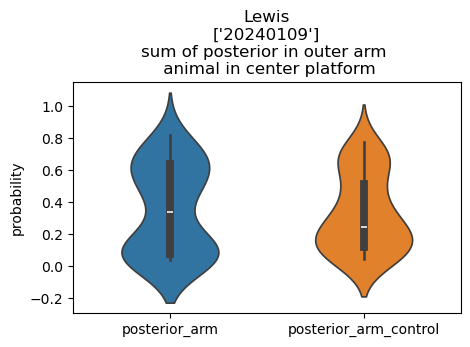

In [10]:
fig,axe = plt.subplots(1,1,figsize = (5,3))

violin_dict = {}
label1 = "posterior_arm"
label2 = "posterior_arm_control"
violin_dict[label1] = posterior_arm
violin_dict[label2] = posterior_arm_control

xticks = [f"{label} \n N = {len(violin_dict[label])}" for label in violin_dict]
                            
ax = sns.violinplot(violin_dict, width=0.5, ax = axe)
_, p_value = ranksums(violin_dict[label1], violin_dict[label2])
print("p_value",p_value)
if p_value < 0.05:
    # adding statistical annotation
    annotations = [(label1, label2, np.round(p_value, 4))]
    starbars.draw_annotation(annotations)
    
axe.set_title(f"{animal}\n{list_of_days}\nsum of posterior in outer arm \n animal in center platform")
axe.set_ylabel("probability")

## Play ground

1


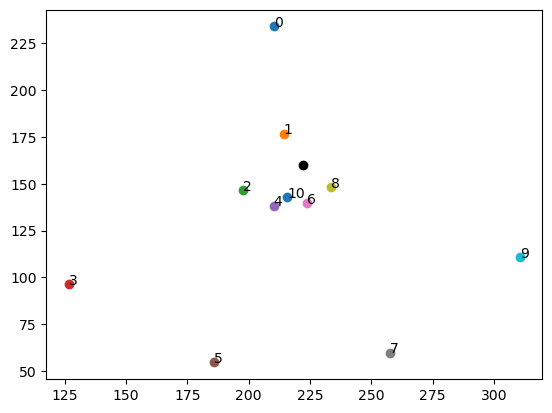

In [9]:
#p_rat = [222,140] returns True
#p_rat = [222,130] returns False
p_rat = [222,160]

n_ind = 0
for n in node_positions:
    plt.scatter(n[0],n[1])
    plt.text(n[0],n[1],str(n_ind))
    n_ind += 1

plt.scatter(p_rat[0],p_rat[1],color = 'k')
print(is_rat_interior(p_rat))